# SUV Purchase Prediction

This notebook builds a **logistic regression** model to predict whether a customer will purchase an SUV, based on their **age** and **estimated salary**.

Workflow: load data -> explore -> select features -> split into train/test sets -> train a model -> evaluate it -> improve it with feature scaling.

## 1. Import Libraries

Standard libraries for data handling (pandas, numpy) and visualization (matplotlib, seaborn).

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Load Dataset

Read the SUV purchase dataset into a pandas DataFrame.

In [8]:
dataset = pd.read_csv("suv_data.csv")

Preview the first 12 rows to check the structure and column names.

In [9]:
dataset.head(12)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


## 3. Exploratory Data Analysis

Visualize the relationship between the features and the target to get a feel for the data before modeling.

<Axes: >

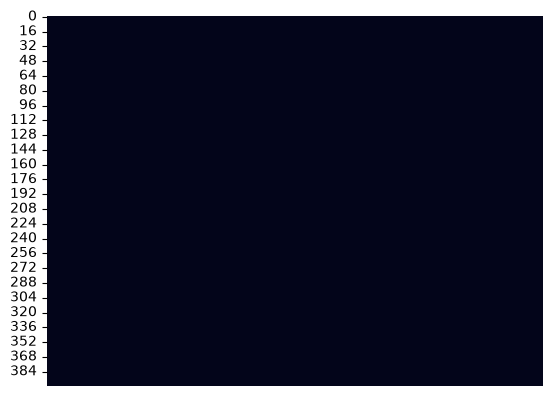

In [10]:
dataset.isnull()
dataset.isnull().sum()
sns.heatmap(dataset.isnull(), xticklabels=False,cbar=False)

## 4. Select Features and Target

Use Age and EstimatedSalary (columns 2 and 3) as input features (x), and Purchased (column 4) as the target (y).

In [11]:
x = dataset.iloc[:,[2,3]].values
y = dataset.iloc[:,[4]].values

## 5. Train-Test Split

Hold out 25% of the data for testing so the model can be evaluated on unseen samples.

In [90]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=10
)

## 6. Train a Logistic Regression Model (Raw Features)

Fit a LogisticRegression model directly on the unscaled features and check its accuracy on the test set.

In [91]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
predict = model.predict(x_test)
model.score(x_test,y_test)

c:\Users\sssan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1368: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.9

### Evaluate the Model

Check precision, recall, and F1-score for each class.

In [92]:
from sklearn.metrics import classification_report
classification_report(y_test,predict)

'              precision    recall  f1-score   support\n\n           0       0.93      0.93      0.93        69\n           1       0.84      0.84      0.84        31\n\n    accuracy                           0.90       100\n   macro avg       0.88      0.88      0.88       100\nweighted avg       0.90      0.90      0.90       100\n'

Look at the confusion matrix to see exactly how many predictions were correct vs. incorrect for each class.

In [93]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,predict)

array([[64,  5],
       [ 5, 26]])

Confirm the overall accuracy score.

In [94]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict)

0.9

## 7. Improve the Model with Feature Scaling

Logistic regression can be sensitive to features that are on very different scales (age: ~18-60, salary: ~15,000-150,000). Apply StandardScaler to standardize both features, then retrain and re-evaluate the model.

In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model.fit(x_train_scaled, y_train.ravel())
predict = model.predict(x_test_scaled)

model.score(x_test_scaled, y_test.ravel())

0.9

Re-check accuracy on the scaled features.

In [99]:
y_pred = model.predict(x_test_scaled)
accuracy_score(y_test.ravel(), y_pred) * 100
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)%100

0.9

## 8. Conclusion

The logistic regression model achieves **90% accuracy** on the test set, with solid precision and recall for both classes (0.93 / 0.93 for non-purchasers, 0.84 / 0.84 for purchasers). Feature scaling with StandardScaler did not change accuracy for this dataset, since logistic regression's coefficients adapt to unscaled features reasonably well here - but scaling remains good practice generally, especially for gradient-based or distance-based algorithms.